AI 212 S2 <br>
Acilo, Callagon, Franco, Munar

# Equivalent Distributions

## Import

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.stats import binom, norm, poisson
from scipy.special import factorial

## Binomial and Normal Equivalence

The Binomial Distribution $X\sim Binomial(n, p)$ is a discrete probability distribution having the probability mass function of:
$$
  P(X=x) = \binom{n}{x} p^k (1-p)^x
$$

The Normal Distribution $X\sim \mathcal{N}(\mu, \sigma^2)$, on the other hand, is a continuous probability distribution having the probability density function of:
$$
  P(X=x) = \frac{1}{\sqrt{2\pi \sigma^2}} exp\left(\frac{-(x-\mu)^2}{2\sigma^2}\right)
$$

According to the Central Limit Theorem (CLT), the sum of a large number of independent and identically distributed (iid) random variables approaches a normal distribution, regardless of the original distribution.

Let us also state that a binomial distribution is simply the sum of multiple Bernoulli Distributions. This is analogous to one choosing from a population and finding the sum of those samples, and per CLT, the distribution of the sum of the samples is a normal distribution, provided that we have enough sample size.

By performing simulations on different n values, we compute for both the binomial probability mass function and the normal probability density function, and then superimpose the plot of both. It can be seen that as you increase the number of n, the plots of the binomial pmf approaches the normal pdf.

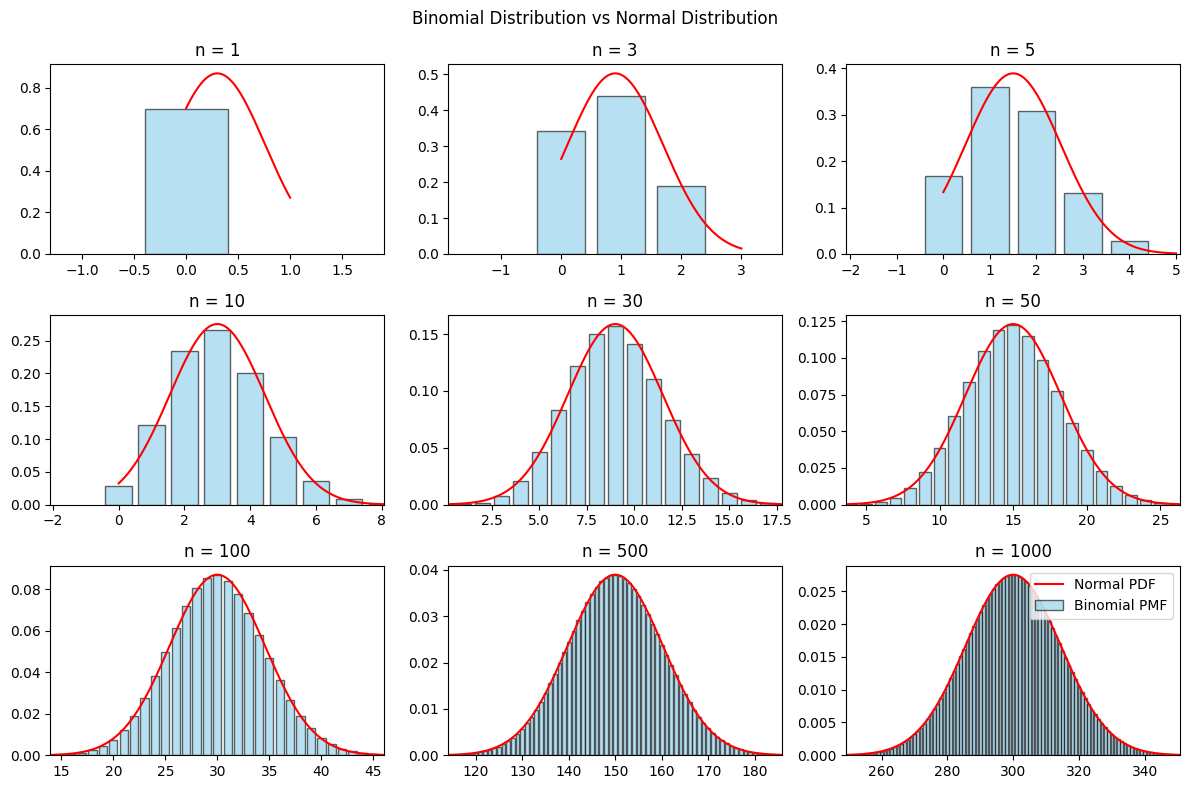

In [2]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 8))
axes = np.ravel(axes)
nlist = [1, 3, 5, 10, 30, 50, 100, 500, 1000]

for n, ax in zip(nlist, axes):
    # binomial distribution
    p = 0.3
    q = 1 - p
    x = np.arange(0, n)
    binom_prob = binom.pmf(x, n, p)

    # normal distribution
    mu, sigma = n*p, np.sqrt(n*p*q)
    x_cont = np.linspace(0, n, 1000)
    normal_prob = norm.pdf(x_cont, mu, sigma)

    # plot
    ax.bar(x, binom_prob, alpha=0.6, label='Binomial PMF', edgecolor='black',
           color='skyblue')
    ax.plot(x_cont, normal_prob, 'r-', label='Normal PDF')

    ax.set_title(f'n = {n}')
    ax.set_xlim([mu-3.5*sigma, mu+3.5*sigma])

plt.suptitle('Binomial Distribution vs Normal Distribution')
plt.tight_layout()
plt.legend()
plt.show()

Based from the 9 subplots, the binomial distribution has a very discrete plot for low $n$ values, but as you increase the $n$, it becomes obvious that it indeed approaches the bell-curve shape of a normal distribution.

## Binomial and Poisson Equivalence

Poisson Distribution $X\sim Poisson(\lambda)$ is a kind of discrete distribution having a probability mass function of:
$$
  P(X=x) = \frac{\lambda ^ x e^{-\lambda}}{x!}
$$

The limiting case $n \to \infty$ and $p \to 0$ for a given $\lambda = np$ for the Binomial Distribution's probability mass function can be shown to approach the probability mass function of a Poisson Distribution.

$$
  P(X=x) = \binom{n}{x} p^x (1-p)^{n-x}
$$

We assume for a constant $\lambda = np$, our $p$ adjusts to the increase of $n$
$$
  p = \frac{\lambda}{n}
$$

$$
  P(X=x) = \binom{n}{x} \left(\frac{\lambda}{n}\right)^x \left(1-\frac{\lambda}{n}\right)^{n-x}
$$

Let us evaluate each major multiplicand from the equation. Starting from the binomial term

$$
\binom{n}{x} = \frac{n(n-1)(n-1)...(n-x+1)}{x!} \\
\binom{n}{x} = \frac{n^k}{x!} \left(1-\frac{1}{n}\right) \left(1-\frac{2}{n}\right)...\left(1-\frac{x-1}{n}\right) \\
\lim_{n\to\infty} \binom{n}{x} = \frac{n^x}{x!}
$$

Notice that as $n$ approaches infinity, the other terms become 1, with only the first term surviving.

For the next multiplicand,

$$
\left(\frac{\lambda}{n}\right)^x = \frac{\lambda^x}{n^x} \\
$$

Then for the last multiplicand,

$$
\lim_{n\to\infty} \left(1-\frac{\lambda}{n}\right)^{n-x} = \lim_{n\to\infty} \left(1-\frac{\lambda}{n}\right)^{n} \\
\lim_{n\to\infty} \left(1-\frac{\lambda}{n}\right)^{n} = e^{-\lambda}
$$

The exponent is reduced to $n$ since $x$ becomes negligible. Then, the whole term is simplified based on the definition of $e$.

By combining all the terms, the Binomial PMF becomes the Poisson PMF.

$$
\lim_{n\to\infty} P(X=x) = \frac{n^x}{x!} \frac{\lambda^x}{n^x} e^{-\lambda} \\
\lim_{n\to\infty} P(X=x) = \frac{e^{-\lambda} \lambda^x}{x!}
$$

In the next cell is a demonstration of how the Binomial Distribution approaches the Poisson Distribution as $n$ increases (which in turn decreases $p$ for a given $\lambda$).

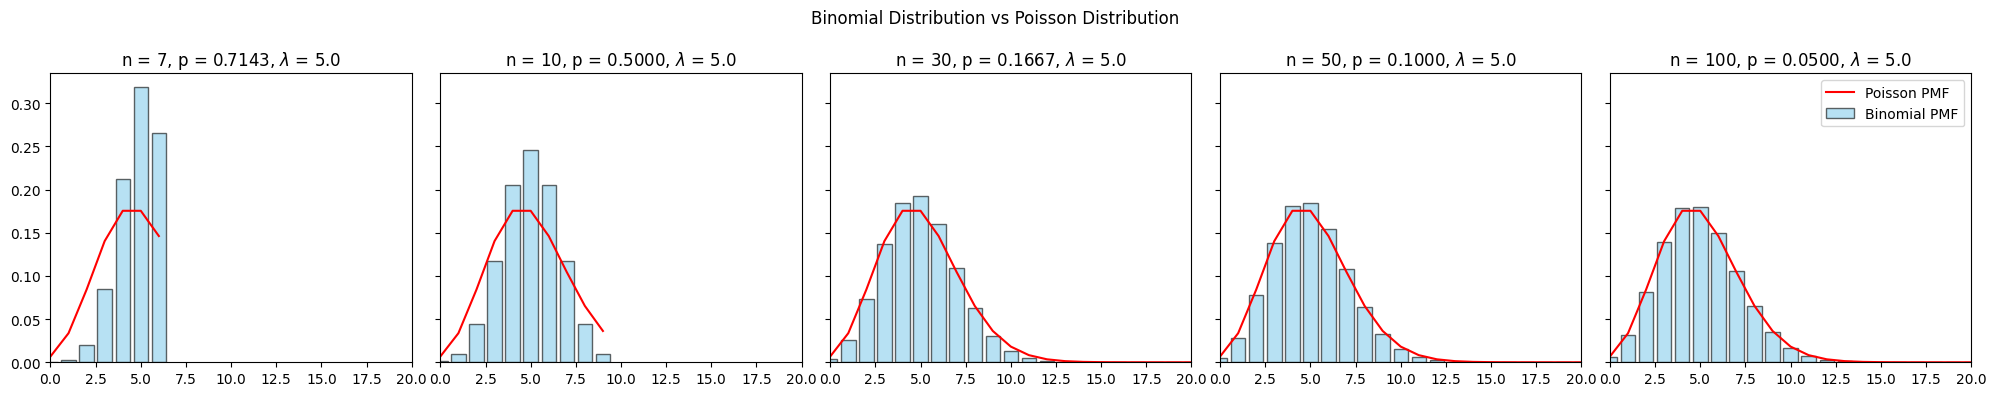

In [3]:
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 4), sharey=True, sharex=True)
axes = np.ravel(axes)
nlist = [7, 10, 30, 50, 100]

for n, ax in zip(nlist, axes):
    # binomial distribution
    lambda_ = 5
    p = lambda_ / n
    x = np.arange(0, n)
    binom_prob = binom.pmf(x, n, p)

    # poisson distribution
    lambda_ = n*p
    poisson_prob = lambda_ ** x * np.exp(-lambda_) / factorial(x)

    # plot
    ax.bar(x, binom_prob, alpha=0.6, label='Binomial PMF', edgecolor='black',
           color='skyblue')
    ax.plot(x, poisson_prob, 'r-', label='Poisson PMF')

    ax.set_title(rf'n = {n}, p = {p:.4f}, $\lambda$ = {lambda_}')
    ax.set_xlim([0, 20])

plt.suptitle('Binomial Distribution vs Poisson Distribution')
plt.tight_layout()
plt.legend()
plt.show()

In the simulation, we increase the $n$ and this causes $p$ to decrease since the $\lambda$ parameter must be constant. As observed, the histograms of a binomial distribution closely follows the poisson distribution for the limiting case previously defined.

## Exponential and Poisson Equivalence

Let $X_1, X_2, X_3,...$ be the interarrival times which are i.i.d. and has a rate of $\lambda$. The probability density function is

$$
f_X(x)=\lambda e^{-\lambda x}, ~~~~~ x\geq 0\\
$$

Additionally, let $S_n=X_1+X_2+...+X_n$ be the arrival time of the n-th event.

Our interest lies in $N(T)$ which is the number of arrivals by time $T$.

A key idea here is that
$$
N(T)=n \iff S_n \leq T \lt S_{n+1}
$$
or simply the n-th arrival must occur before $T$ but the (n+1)-th arrival occurs after $T$.

Let us compute $P(N(T)=n)$
$$
P(N(T)=n)=P(S_n \leq T \lt S_{n+1})
$$

It is known that the sum of $n$ i.i.d. exponential variables follows a Gamma distribution $S_n \sim Gamma(n,\lambda)$
$$
f_{S_n}(t)=\frac{\lambda^n t^{n-1} e^{-\lambda t}}{(n-1)!}
$$

If the n-th arrival happened at time $s$, what is the probability that the (n+1)th arrival happens after time $T$? This is symbolized by

$$
X_{n+1} > T - s \\
P(X_{n+1} > T - s) = e^{-\lambda (T-s)}
$$

By integrating over all the possible values of $s$ from 0 to $T$ that the nth arrival $S_n$ could have taken, it leads to

$$
P(N(T)=n) = \int^T_0 P(X_{n+1} > T - s)\cdot f_{S_n}(s)ds
$$

The equation above can be understood as a result of law of total probability where we integrate the product of the probability that there will be no next arrival in $[s, T]$ and the pdf of the nth arrival at time $s$.

$$
P(N(t)=n) = \int^T_0 e^{-\lambda (T-s)} \cdot \frac{\lambda^n s^{n-1} e^{-\lambda s}}{(n-1)!} ds \\
P(N(t)=n) = \int^T_0 e^{-\lambda T} e^{\lambda s} \cdot \frac{\lambda^n s^{n-1} e^{-\lambda s}}{(n-1)!} ds \\
P(N(t)=n) = e^{-\lambda T} \cdot \frac{\lambda^n }{(n-1)!} \int^T_0 s^{n-1} ds \\
P(N(t)=n) = e^{-\lambda T} \cdot \frac{\lambda^n }{(n-1)!} \frac{T^n}{n} \\
P(N(t)=n) = \frac{e^{-\lambda T} (\lambda T)^n }{n!}
$$

This is the poisson's distribution for parameter $\lambda T$

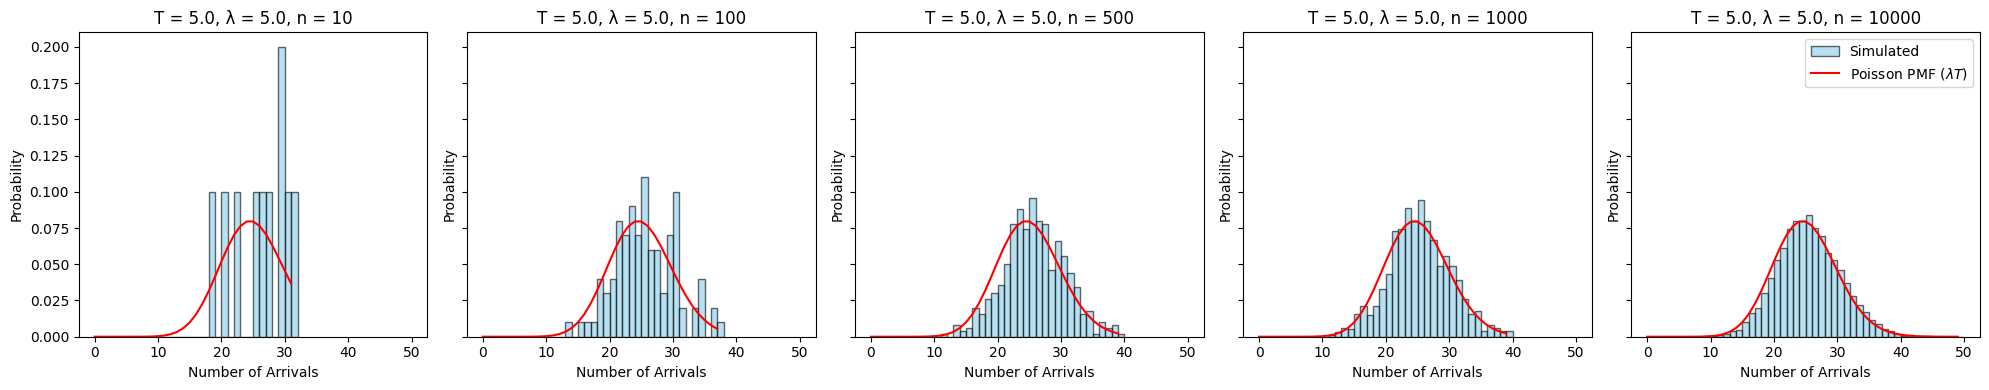

In [4]:
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 4), sharey=True, sharex=True)
axes = np.ravel(axes)
nlist = [10, 100, 500, 1000, 10000]


def simulate_arrivals(lambda_rate, T):
    arrivals = 0
    time = 0.0
    while True:
        # rng = np.random.default_rng(seed=42)
        interarrival = np.random.exponential(1 / lambda_rate)
        time += interarrival
        if time > T:
            break
        arrivals += 1
    return arrivals


for n, ax in zip(nlist, axes):
    # Parameters
    lambda_rate = 5.0  # events per unit time
    T = 5.0  # total observation time

    # Run simulation multiple times to see distribution
    np.random.seed(42)
    counts = [simulate_arrivals(lambda_rate, T) for _ in range(n)]

    # Simulation histogram
    ax.hist(counts, bins=range(max(counts)+2), density=True, alpha=0.6,
            color='skyblue', edgecolor='black', label='Simulated')

    # Poisson distribution (actual)
    x = np.arange(0, max(counts)+1)
    poisson_prob = poisson.pmf(x, mu=lambda_rate * T)
    ax.plot(x, poisson_prob, 'r-', label='Poisson PMF ($\\lambda T$)')

    ax.set_title(f"T = {T}, λ = {lambda_rate}, n = {n}")
    ax.set_xlabel("Number of Arrivals")
    ax.set_ylabel("Probability")

plt.legend()
plt.tight_layout()
plt.show()

For low $n$ (e.g. $n=10$, $n=100$), it can be observed that the histograms do not perfectly follow the actual distribution. The reason for this is the sampling variability such as noise from the random generator. But as you increase the sample size, Law of Large Numbers comes into play and decreases the the effect of randomness. The effect of the increasing $n$ is visible in the plots. The first few plots look ragged and barely follows the actual distribution, but as you get large samples, the histograms become smoother and closely follows the PMF plot.